# Aula 16 - Fundamentos de Redes Neurais - Parte 2 (Multi-Layer Perceptron - MLP & Backpropagation)

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  

---

> [!NOTE]
> 🔙 **De onde viemos:** Na Aula 15, aprendemos a estrutura de um único Neurônio Artificial e provamos que ele é incapaz de resolver problemas não-lineares (como o XOR). Para resolver problemas complexos do mundo real, precisamos empilhar neurônios em camadas estruturadas.
> 🎯 **Objetivo Principal da Aula:** Dominar a arquitetura das **Redes Neurais Multicamadas (MLP - Multi-Layer Perceptron)**, compreendendo o fluxo de **Feedforward**, o cálculo da função de custo (**Loss Function**) e a atualização de pesos via **Backpropagation & Gradiente Descendente**, utilizando o `MLPClassifier` do Scikit-Learn e inspecionando curvas de aprendizado (`loss_curve_`).
> 🚀 **Para onde vamos:** Na próxima aula ('Construção de Redes Neurais com TensorFlow/Keras - Parte 1'), migraremos para a ferramenta definitiva utilizada pelas gigantes da tecnologia (Google, Netflix, Meta): o ecossistema **TensorFlow / Keras**.

---

## Organização Tática da Aula

| Módulo | Atividade | Foco Pedagógico |
| :--- | :--- | :--- |
| **Módulo 1** | **Fundamentação Teórica & A Arquitetura MLP** | Camada de Entrada, Camadas Ocultas (*Hidden Layers*) e Camada de Saída. |
| **Módulo 2** | **O Ciclo de Aprendizado: Feedforward ➔ Loss ➔ Backpropagation** | Como a rede calcula a previsão, mede a Perda (Loss) e volta atualizando os pesos via Gradiente Descendente. |
| **Módulo 3** | **Prática Guiada no Google Colab** | 8 blocos de código em Python minuciosamente comentados linha por linha com caixas de dúvidas. |
| **Módulo 4** | **Prática Orientada & Experimentação Fácil** | Classificação de diagnóstico médico com MLPClassifier alterando o número de neurônios nas camadas ocultas. |
| **Módulo 5** | **Checklist de Autonomia & Bibliografia** | Autoavaliação do estudante e referências oficiais. |

---

## Módulo 1: Fundamentação Teórica & A Arquitetura Multicamadas

### 1.1 O Multi-Layer Perceptron (MLP)
Na Aula 15, vimos que um único Perceptron não consegue resolver problemas não-lineares. Para resolver isso, conectamos neurônios em **camadas sucessivas**:

```mermaid
graph LR
    subgraph Camada Entrada (Input)
    X1["x₁ (Atributo 1)"]
    X2["x₂ (Atributo 2)"]
    end
    subgraph Camada Oculta (Hidden Layer)
    H1["◯ Neurônio H₁"]
    H2["◯ Neurônio H₂"]
    end
    subgraph Camada Saída (Output)
    Y["◯ Saída ŷ"]
    end
    X1 --> H1 & H2
    X2 --> H1 & H2
    H1 & H2 --> Y
```

> [!TIP]
> 🧠 **Analogia Geek — Como o Cérebro de uma IA Aprende:**
> Imagine que a Rede Neural está jogando um videogame retro. No primeiro passe (**Feedforward**), ela aperta os botões aleatoriamente e morre. A tela de *Game Over* mostra a pontuação de erro (**Loss Function**). Então, uma onda de choque de aprendizado percorre o cérebro da IA de trás para frente (**Backpropagation**), ajustando os reflexos (pesos $w$) para que no próximo passe a IA alcance o final da fase!

> [!NOTE]
> 💡 **Curiosidade da Aula — Geoffrey Hinton & O Artigo de 1986 na Nature:**
> O algoritmo de Backpropagation (Retropropagação do Erro) foi revolucionado e popularizado em **1986 por David Rumelhart, Geoffrey Hinton e Ronald Williams** em um artigo histórico publicado na revista *Nature*. Esse artigo mostrou ao mundo como usar a Regra da Cadeia do Cálculo diferencial para treinar redes profundas. Geoffrey Hinton é considerado um dos "Padrinhos da IA" e venceu o Prêmio Turing por este feito!  
> 🔗 [3Blue1Brown: Neural networks & Backpropagation (YouTube)](https://www.youtube.com/watch?v=aircAruvnKk)  
> 🔗 **Documentação Scikit-Learn:** [scikit-learn MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

> [!IMPORTANT]
> 💡 **Em 1 Frase:** Um Multi-Layer Perceptron (MLP) possui uma ou mais camadas ocultas de neurônios intermediários, capacitando a rede a aprender fronteiras de decisão complexas e não-lineares.

---

## Módulo 2: O Mecanismo por Dentro & O Ciclo de Treinamento

### 2.1 As 4 Etapas do Ciclo de Treinamento
1. **Feedforward:** Os dados passam da esquerda para a direita calculando $\hat{y}$.
2. **Loss Function:** Mede o erro comparando a resposta real $y$ com $\hat{y}$.
3. **Backpropagation:** Calcula o gradiente do erro da direita para a esquerda.
4. **Gradient Descent:** Atualiza cada peso: $w_{novo} = w_{antigo} - (\eta \cdot \text{Gradiente})$.

> [!IMPORTANT]
> 💡 **Em 1 Frase:** O ciclo de aprendizado transmite o sinal para a frente (Feedforward), mede a perda de erro (Loss) e propaga o ajuste de pesos para trás (Backpropagation) usando Gradiente Descendente.

---

## Módulo 3: Prática Guiada no Google Colab

Abra o [Google Colab](https://colab.research.google.com), crie um novo Notebook e acompanhe os blocos de código abaixo.

> [!NOTE]
> **Roteiro de estudo:** uma MLP segue o mesmo ciclo já conhecido: preparar dados, treinar, prever e avaliar. As camadas ocultas são etapas internas de transformação. Nesta aula, acompanhe o fluxo e a curva de perda; backpropagation e gradiente são explicações do ajuste interno, não comandos que você precisa escrever manualmente.

---

### Bloco 3.1 — Importação de Módulos e Carregando o Dataset Médico

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Qual módulo do Scikit-Learn implementa Redes Neurais Multicamadas?**  
> O `sklearn.neural_network.MLPClassifier` implementa redes neurais densas (*Dense Neural Networks*) para tarefas de classificação.

In [1]:
# 1. Importamos as bibliotecas fundamentais de dados, gráficos e redes neurais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# 2. Carregamos o dataset médico de diagnósticos de câncer
dados_brutos_cancer = load_breast_cancer()
matriz_entradas_medicas = dados_brutos_cancer.data
vetor_respostas_medicas = dados_brutos_cancer.target

# 3. Exibimos as dimensões da base médica
print("--- DATASET MÉDICO CARREGADO ---")
print(f"📐 Dimensão do Dataset: {matriz_entradas_medicas.shape} (569 amostras, 30 atributos médicos)")

--- DATASET MÉDICO CARREGADO ---
📐 Dimensão do Dataset: (569, 30) (569 amostras, 30 atributos médicos)


---

### Bloco 3.2 — Divisão Treino e Teste com Estratificação

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que reservamos 25% para teste?**  
> Para garantir que a rede neural seja avaliada apenas em pacientes reais que nunca participaram do processo de cálculo dos pesos durante o Backpropagation.

In [2]:
# 1. Dividimos a base: 75% para treino e 25% para teste com estratificação da classe
matriz_entradas_treino, matriz_entradas_teste, vetor_respostas_treino, vetor_respostas_teste = train_test_split(
    matriz_entradas_medicas, 
    vetor_respostas_medicas, 
    test_size=0.25, 
    random_state=42, 
    stratify=vetor_respostas_medicas
)

# 2. Exibimos a contagem das amostras separadas
print("--- DIVISÃO DE DADOS (TREINO E TESTE) ---")
print(f"📦 Treino: {len(matriz_entradas_treino)} amostras | 🧪 Teste: {len(matriz_entradas_teste)} amostras")

--- DIVISÃO DE DADOS (TREINO E TESTE) ---
📦 Treino: 426 amostras | 🧪 Teste: 143 amostras


---

### Bloco 3.3 — Padronização de Escala (`StandardScaler`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que a padronização de escala é INDISPENSÁVEL para Redes Neurais?**  
> Porque o Backpropagation calcula derivadas parciais dos pesos. Se os dados não estiverem na mesma escala (`StandardScaler`), os gradientes explodem ou somem (*Exploding/Vanishing Gradients*), impedindo a rede de aprender.

In [3]:
# 1. Instanciamos e aplicamos o escalonador padronizado
escalonador_padronizado = StandardScaler()
matriz_treino_padronizada = escalonador_padronizado.fit_transform(matriz_entradas_treino)
matriz_teste_padronizada = escalonador_padronizado.transform(matriz_entradas_teste)

# 2. Exibimos confirmação no console
print("--- PADRONIZAÇÃO DE ESCALA PREVIA ---")
print("✅ Dados padronizados com Média = 0 e Desvio Padrão = 1.")

--- PADRONIZAÇÃO DE ESCALA PREVIA ---
✅ Dados padronizados com Média = 0 e Desvio Padrão = 1.


---

### Bloco 3.4 — Instanciando o `MLPClassifier` com 2 Camadas Ocultas

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que significa a tupla `hidden_layer_sizes=(16, 8)`?**  
> Significa que a rede neural terá **duas camadas ocultas**: a primeira com 16 neurônios e a segunda com 8 neurônios. O otimizador `solver='adam'` é o algoritmo de gradiente mais eficiente.

In [4]:
# 1. Instanciamos a Rede Neural MLP com 2 camadas ocultas (16 e 8 neurônios)
modelo_rede_neural_mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8), # 1ª camada com 16 neurônios, 2ª com 8 neurônios
    activation='relu',          # Função de ativação ReLU nas camadas ocultas
    solver='adam',              # Otimizador de gradiente descendente Adam
    max_iter=300,               # Máximo de 300 épocas de treinamento
    random_state=42
)

# 2. Exibimos a estrutura configurada
print("--- ARQUITETURA DA REDE NEURAL MULTICAMADAS ---")
print("Estrutura configurada:", modelo_rede_neural_mlp)

--- ARQUITETURA DA REDE NEURAL MULTICAMADAS ---
Estrutura configurada: MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=300, random_state=42)


---

### Bloco 3.5 — Treinando a Rede Neural Multicamadas (`fit`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que o comando `.fit()` executa em uma Rede Neural?**  
> Ele executa centenas de épocas iterativas de **Feedforward** (calculando o erro da rede) e **Backpropagation** (reajustando os milhares de pesos da rede para diminuir a perda).

In [5]:
# 1. O MOMENTO DO APRENDIZADO DEEP LEARNING: A rede neural executa as épocas
modelo_rede_neural_mlp.fit(matriz_treino_padronizada, vetor_respostas_treino)

# 2. Exibimos o total de épocas necessárias para a convergência dos pesos
print("🎉 REDE NEURAL MULTICAMADAS (MLP) TREINADA COM SUCESSO!")
print(f"Épocas executadas até convergência: {modelo_rede_neural_mlp.n_iter_}")

🎉 REDE NEURAL MULTICAMADAS (MLP) TREINADA COM SUCESSO!
Épocas executadas até convergência: 300


C:\Users\eduar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


---

### Bloco 3.6 — Avaliando a Acurácia no Teste (`accuracy_score`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Como testamos se a rede neural realmente aprendeu?**  
> Geramos previsões com `.predict()` nos dados de teste padronizados e calculamos a acurácia de acertos.

In [6]:
# 1. A rede neural gera previsões para as amostras não vistas de teste
previsoes_rede_neural = modelo_rede_neural_mlp.predict(matriz_teste_padronizada)

# 2. Calculamos a acurácia final
acuracia_rede_neural = accuracy_score(vetor_respostas_teste, previsoes_rede_neural)

# 3. Exibimos o resultado em porcentagem
print("--- AVALIAÇÃO DA REDE NEURAL NO TESTE ---")
print(f"📊 Acurácia Final da Rede Neural MLP no Teste: {acuracia_rede_neural * 100:.2f}%")

--- AVALIAÇÃO DA REDE NEURAL NO TESTE ---
📊 Acurácia Final da Rede Neural MLP no Teste: 96.50%


---

### Bloco 3.7 — Plotando a Curva de Aprendizado (Queda da Perda / `loss_curve_`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Como interpretar a Curva de Perda (`loss_curve_`)?**  
> É o gráfico que mostra a queda do erro a cada época. O ideal é ver a linha vermelha caindo drasticamente e se estabilizando perto de zero.

🎨 Exibindo a curva de aprendizado (Loss Curve) no Colab...


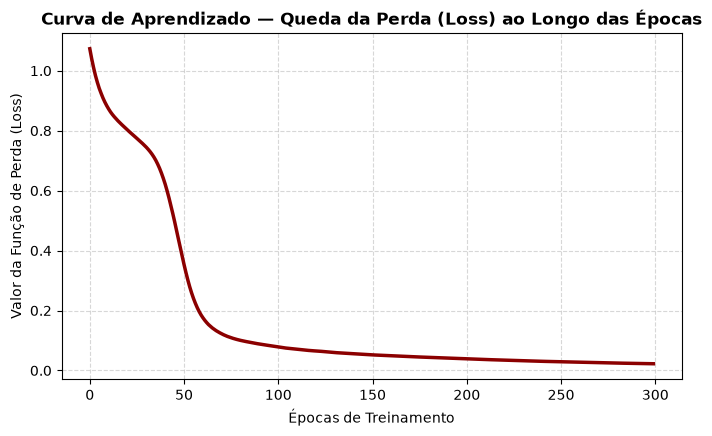

In [7]:
# 1. Definimos o tamanho da figura do gráfico
plt.figure(figsize=(8, 4.5))

# 2. Plotamos a trajetória da perda (loss) armazenada no atributo .loss_curve_
plt.plot(modelo_rede_neural_mlp.loss_curve_, color='darkred', linewidth=2.5)

# 3. Adicionamos rótulos explicativos aos eixos
plt.title("Curva de Aprendizado — Queda da Perda (Loss) ao Longo das Épocas", fontweight='bold')
plt.xlabel("Épocas de Treinamento")
plt.ylabel("Valor da Função de Perda (Loss)")
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Renderizamos o gráfico no notebook
print("🎨 Exibindo a curva de aprendizado (Loss Curve) no Colab...")
plt.show()

---

### Bloco 3.8 — Exibindo o Relatório Completo de Métricas (`classification_report`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que verificar o `classification_report` em diagnósticos médicos?**  
> Porque em medicina precisamos de um **Recall** próximo de 100% para a classe de tumores benignos/malignos, garantindo que nenhum doente fique sem tratamento.

In [8]:
# 1. Exibimos o relatório estatístico detalhado de classificação
print("--- RELATÓRIO COMPLETO DA REDE NEURAL MLP ---")
print(classification_report(vetor_respostas_teste, previsoes_rede_neural))

--- RELATÓRIO COMPLETO DA REDE NEURAL MLP ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        53
           1       0.99      0.96      0.97        90

    accuracy                           0.97       143
   macro avg       0.96      0.97      0.96       143
weighted avg       0.97      0.97      0.97       143



---

## Módulo 4: Prática Orientada & Experimentação Fácil

### Roteiro de Personalização para o Estudante:
Altere a estrutura das camadas ocultas da Rede Neural MLP abaixo para personalizar a sua arquitetura:

1. **Altere a quantidade de neurônios nas camadas:** Na linha `minhas_camadas_ocultas = (32, 16)`, experimente alterar para `(64, 32)` ou `(16,)`.
2. **Re-execute e observe:** Veja como a curva de perda desce no gráfico e qual a nova acurácia obtida!

--- RELATÓRIO DA SUA REDE NEURAL (Camadas=(32, 16)) ---
📊 Acurácia Obtida no Teste: 98.60%


C:\Users\eduar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


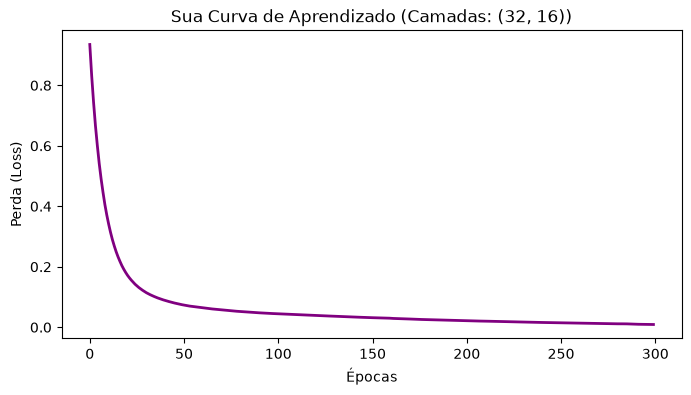

In [9]:
# =============================================================================
# CÓDIGO BASE PRONTO PARA SUA EXPERIMENTAÇÃO
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. Carregamos e preparamos o dataset médico
dados_cancer = load_breast_cancer()
matriz_treino, matriz_teste, respostas_treino, respostas_teste = train_test_split(dados_cancer.data, dados_cancer.target, test_size=0.25, random_state=42)

escalonador = StandardScaler()
matriz_treino_padronizada = escalonador.fit_transform(matriz_treino)
matriz_teste_padronizada = escalonador.transform(matriz_teste)

# -----------------------------------------------------------------------------
# STEP 1: PASSO DE EXPERIMENTAÇÃO DO ALUNO — ALTERE AS CAMADAS OCULTAS ABAIXO:
# -----------------------------------------------------------------------------
minhas_camadas_ocultas = (32, 16) # Tente mudar para (64, 32) ou (16,) neurônios!

# 2. Instanciamos a rede neural com a arquitetura escolhida pelo estudante
rede_neural_estudante = MLPClassifier(
    hidden_layer_sizes=minhas_camadas_ocultas,
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# 3. Treinamos a rede e calculamos a acurácia final
rede_neural_estudante.fit(matriz_treino_padronizada, respostas_treino)
acuracia_estudante_final = accuracy_score(respostas_teste, rede_neural_estudante.predict(matriz_teste_padronizada))

# 4. Exibimos o relatório e o gráfico de perda
print(f"--- RELATÓRIO DA SUA REDE NEURAL (Camadas={minhas_camadas_ocultas}) ---")
print(f"📊 Acurácia Obtida no Teste: {acuracia_estudante_final * 100:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(rede_neural_estudante.loss_curve_, color='purple', linewidth=2)
plt.title(f"Sua Curva de Aprendizado (Camadas: {minhas_camadas_ocultas})")
plt.xlabel("Épocas")
plt.ylabel("Perda (Loss)")
plt.show()

---

### 🔮 Aquecimento & Spoiler da Próxima Aula (Para Ir Além)

> [!TIP]
> 🧠 **Conceito-Semente — Bem-vindo ao TensorFlow & Keras!**  
> Montar redes neurais com classes genéricas é ótimo para aprender a teoria, mas para treinar redes profundas com milhares de parâmetros e imagens reais, a indústria usa o **TensorFlow / Keras**. Na **Aula 17**, aprenderemos a sintaxe elegante do `keras.Sequential()` e treinaremos uma rede real para identificar 10 tipos de peças de roupas no famoso dataset **Fashion-MNIST**!
> 
> 🚀 **Desafio Proativo de Autoestudo (Opcional):**  
> No Google Colab, execute: `import tensorflow as tf; print(tf.__version__)` para garantir que o seu ambiente já possui o TensorFlow 2.x pronto para a próxima aula!

---

## Módulo 5: Checklist de Autonomia do Estudante

- [ ] Compreendi a arquitetura de uma Rede Neural MLP (Camada de Entrada, Ocultas e Saída).
- [ ] Entendi o fluxo de propagação direta (*Feedforward*) e retropropagação (*Backpropagation*).
- [ ] Sei o papel do Gradiente Descendente e da Taxa de Aprendizado (*Learning Rate*).
- [ ] Consigo instanciar e treinar um `MLPClassifier` no Scikit-Learn.
- [ ] Sei alterar a quantidade de neurônios nas camadas ocultas e observar a curva de perda.

---

## Referências Bibliográficas & Documentações Oficiais

- 📖 **Livro Texto:** Géron, A. — *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow* (Capítulo 10).
- 🔗 **Documentação Scikit-Learn:** [scikit-learn MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
- 🎥 **Vídeo Recomendado:** [3Blue1Brown: Neural Networks (YouTube)](https://www.youtube.com/watch?v=aircAruvnKk)

---

# 🧪 Extensão Prática Avançada: Laboratório Técnico com Dados Reais (`pratica_real.md`)

> 🔬 **Sobre esta Extensão:**  
> Esta seção adicional consolida o aprendizado com uma abordagem **mais avançada, direta e profissional**, sem dados sintéticos e utilizando datasets reais consagrados da Ciência de Dados.


# Laboratório Prático — Aula 16: Redes Neurais MLP & Curvas de Perda

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  
**Dataset Real:** *Breast Cancer Wisconsin Dataset* (Classificação de Biópsias com Redes Multicamadas)

---

## 🎯 Objetivo do Laboratório
Construir e treinar uma Rede Neural Multicamadas com `MLPClassifier` do Scikit-Learn: estruturar camadas ocultas (`hidden_layer_sizes`), analisar o impacto da taxa de aprendizado e do otimizador (`adam` vs `sgd`), e plotar a **Curva de Aprendizado / Queda da Perda (`loss_curve_`)**.

---

### Passo 1 — Preparando os Dados Médicos Padronizados

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Carregamos o dataset de biópsias
X, y = load_breast_cancer(return_X_y=True)

# 2. Divisão estratificada e padronização (obrigatória para redes neurais!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Treino: {X_train_s.shape[0]} amostras | Teste: {X_test_s.shape[0]} amostras")

Treino: 426 amostras | Teste: 143 amostras


---

### Passo 2 — Treinando o MLPClassifier com 2 Camadas Ocultas

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# 1. Instanciamos a rede neural com 2 camadas ocultas: 64 e 32 neurônios
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# 2. Treinamos a rede com Backpropagation
modelo_mlp.fit(X_train_s, y_train)

# 3. Avaliamos a performance no conjunto de teste
y_pred = modelo_mlp.predict(X_test_s)
print("--- RELATÓRIO DA REDE NEURAL MLP NO TESTE ---")
print(classification_report(y_test, y_pred, target_names=['Maligno', 'Benigno']))

--- RELATÓRIO DA REDE NEURAL MLP NO TESTE ---
              precision    recall  f1-score   support

     Maligno       0.95      0.98      0.96        53
     Benigno       0.99      0.97      0.98        90

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



---

### Passo 3 — Plotando a Curva de Convergência do Erro (`loss_curve_`)

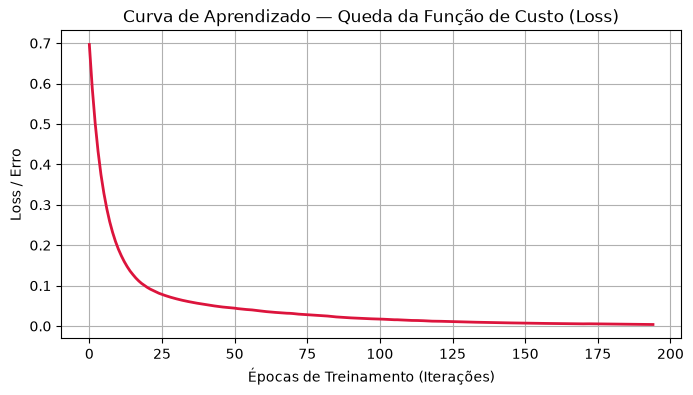

Loss final atingida: 0.003834


In [12]:
# 1. Plotamos a queda do erro época a época
plt.figure(figsize=(8, 4))
plt.plot(modelo_mlp.loss_curve_, color='crimson', lw=2)
plt.title("Curva de Aprendizado — Queda da Função de Custo (Loss)")
plt.xlabel("Épocas de Treinamento (Iterações)")
plt.ylabel("Loss / Erro")
plt.grid(True)
plt.show()

print(f"Loss final atingida: {modelo_mlp.loss_curve_[-1]:.6f}")

---

## 🏆 Desafio Técnico de Validação
Altere o solver para `solver='sgd'` e `learning_rate_init=0.0001` (taxa muito baixa) e observe no gráfico como a curva de perda desce muito mais devagar e não atinge a convergência total em 300 épocas.

In [13]:
# =============================================================================
# ESPAÇO PARA RESOLUÇÃO DO DESAFIO TÉCNICO
# Implemente seu código abaixo para validar o desafio proposto:
# =============================================================================
